In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from util.load import DataLoader

In [18]:
dataloader = DataLoader(data_dir="../data")
ticker = "kxhighny"
max_days = 100
df = dataloader.load_consolidated_daily_data(
    ticker, max_days=max_days, type_="polysignal"
)
daily_df = dataloader.load_daily_data(ticker, max_days=max_days)
df.drop(columns=["time", "ticker", "trade_id"]).head()

100%|██████████| 100/100 [00:00<00:00, 127.94it/s]


,time_to_strike,day_forecast_strike_dev,current_forecast_strike_dev,day_current_forecast_dev,day_wind_gusts_max,day_wind_speed_max,day_cloud_cover_max,day_cloud_cover_min,day_sunshine_duration,hour_wind_gusts,...,yes_price_sentiment_60,count_sentiment_60,yes_price_trend_60,count_agg_120,yes_price_vol_120,count_vol_120,taker_side_sentiment_120,yes_price_sentiment_120,count_sentiment_120,yes_price_trend_120
0,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
1,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
2,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
3,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
4,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4


In [21]:
print(df.columns)

Index(['time', 'trade_id', 'ticker', 'time_to_strike',
       'day_forecast_strike_dev', 'current_forecast_strike_dev',
       'day_current_forecast_dev', 'day_wind_gusts_max', 'day_wind_speed_max',
       'day_cloud_cover_max', 'day_cloud_cover_min', 'day_sunshine_duration',
       'hour_wind_gusts', 'hour_wind_speed', 'hour_cloud_cover',
       'hour_cloud_cover_high', 'kalshi_strike_dev', 'polymk_strike_dev',
       'kalshi_polymk_dev', 'kalshi_day_forecast_dev',
       'polymk_day_forecast_dev', 'day_forecast_percipitation',
       'day_forecast_rain', 'hour_forecast_rain', 'yes_price', 'no_price',
       'taker_side', 'count', 'shift', 'strike_m_5.0', 'strike_m_3.0',
       'strike_m_1.0', 'strike_p_1.0', 'strike_p_3.0', 'strike_p_5.0',
       'polymk_0_strike_m_5.0', 'polymk_1_strike_m_3.0',
       'polymk_2_strike_m_1.0', 'polymk_3_strike_p_1.0',
       'polymk_4_strike_p_3.0', 'polymk_5_strike_p_5.0', 'impact', 'result',
       'outcome', 'count_agg_2', 'yes_price_vol_2', 'coun

In [11]:
day_df = df[df['time_to_strike'] < 60000]

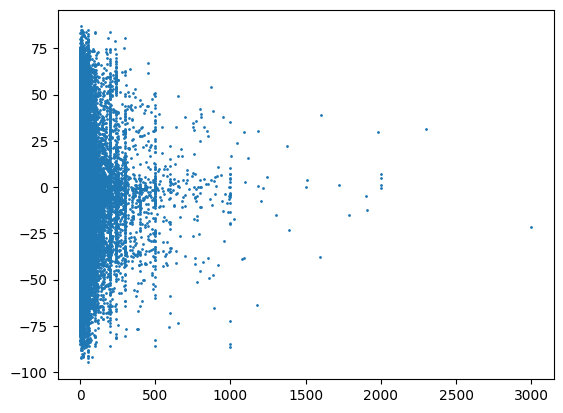

In [17]:
plt.scatter(day_df['count'], day_df['impact'], s = 1)

In [16]:
np.corrcoef(day_df['count'], day_df['impact'])

array([[ 1.        , -0.00817285],
       [-0.00817285,  1.        ]])

In [20]:
print(daily_df.keys())

dict_keys(['2025-02-13', '2025-02-14', '2025-02-15', '2025-02-16', '2025-02-17', '2025-02-18', '2025-02-19', '2025-02-20', '2025-02-21', '2025-02-22', '2025-02-23', '2025-02-24', '2025-02-25', '2025-02-26', '2025-02-27', '2025-02-28', '2025-03-01', '2025-03-02', '2025-03-03', '2025-03-04', '2025-03-05', '2025-03-06', '2025-03-07', '2025-03-08', '2025-03-09', '2025-03-10', '2025-03-11', '2025-03-12', '2025-03-13', '2025-03-14', '2025-03-15', '2025-03-16', '2025-03-17', '2025-03-18', '2025-03-19', '2025-03-20', '2025-03-21', '2025-03-22', '2025-03-23', '2025-03-24', '2025-03-25', '2025-03-26', '2025-03-27', '2025-03-28', '2025-03-29', '2025-03-30', '2025-03-31', '2025-04-01', '2025-04-02', '2025-04-03', '2025-04-04', '2025-04-05', '2025-04-06', '2025-04-07', '2025-04-08', '2025-04-09', '2025-04-10', '2025-04-11', '2025-04-12', '2025-04-13', '2025-04-14', '2025-04-15', '2025-04-16', '2025-04-17', '2025-04-18', '2025-04-19', '2025-04-20', '2025-04-21', '2025-04-22', '2025-04-23', '2025-04-

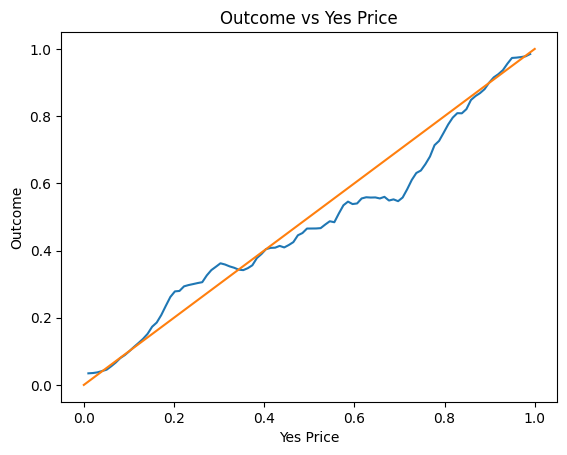

In [35]:
T = np.linspace(0, 100, 100)

base = [x / 100 for x in T]
y = []
for t in T:
    y.append(df[abs(df['yes_price'] - t) < 3]['outcome'].mean())
plt.plot(base, y)
plt.plot(base, base)
plt.xlabel("Yes Price")
plt.ylabel("Outcome")
plt.title("Outcome vs Yes Price")
plt.show()


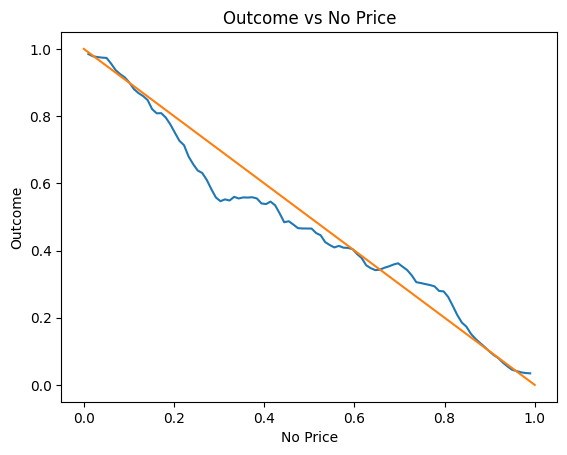

In [38]:
T = np.linspace(0, 100, 100)

base = np.array([x / 100 for x in T])
y = []
for t in T:
    y.append(df[abs(df['no_price'] - t) < 3]['outcome'].mean())
plt.plot(base, y)
plt.plot(base, np.array([1 - x / 100 for x in T]))
plt.xlabel("No Price")
plt.ylabel("Outcome")
plt.title("Outcome vs No Price")
plt.show()
